# House Pricing - Linear Regression

In [1]:

import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [2]:

# Download dataset
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")
print("Files:", os.listdir(path))


Using Colab cache for faster access to the 'housing-prices-dataset' dataset.
Files: ['Housing.csv']


In [3]:

# Load dataset
file_path = os.path.join(path, "Housing.csv")
df = pd.read_csv(file_path)

df.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:

# Features and target
y = df["price"]
X = df.drop(columns=["price"])


In [5]:

# Column separation
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])


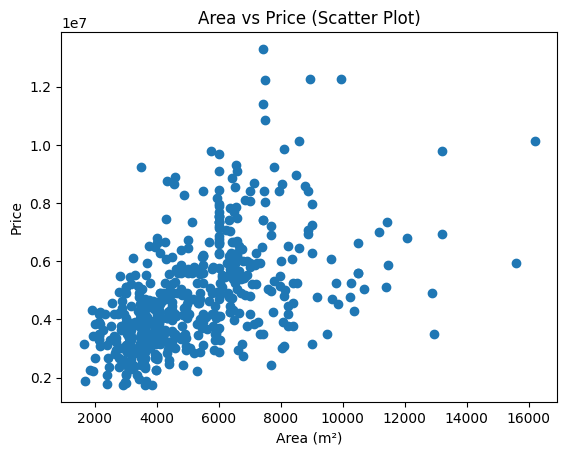

In [6]:
plt.figure()
plt.scatter(df["area"], df["price"])
plt.xlabel("Area (m²)")
plt.ylabel("Price")
plt.title("Area vs Price (Scatter Plot)")
plt.show()

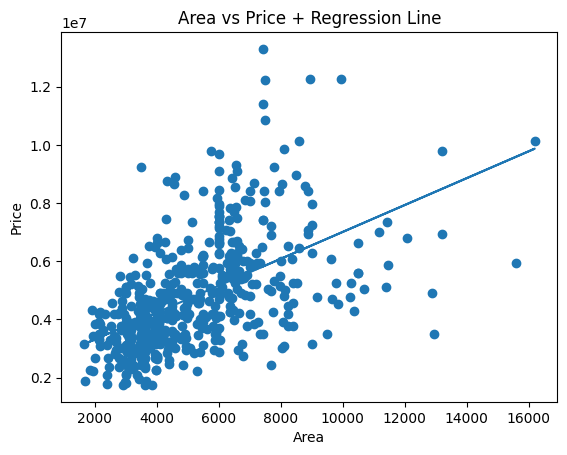

In [7]:
plt.figure()
plt.scatter(df["area"], df["price"])

# regresyon çizgisi
m, b = np.polyfit(df["area"], df["price"], 1)
plt.plot(df["area"], m*df["area"] + b)

plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price + Regression Line")
plt.show()

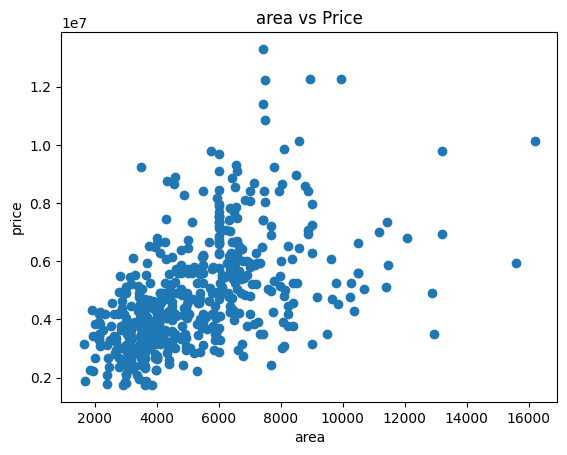

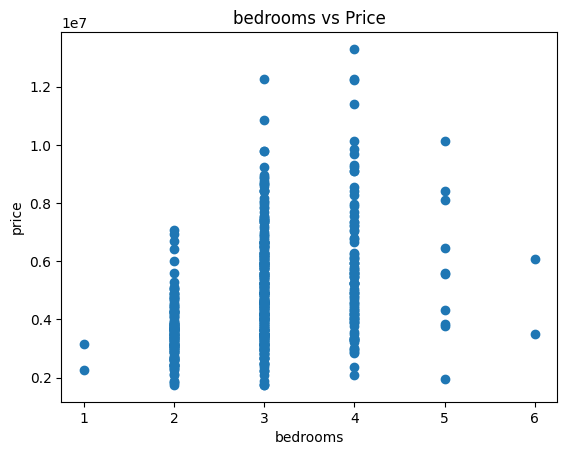

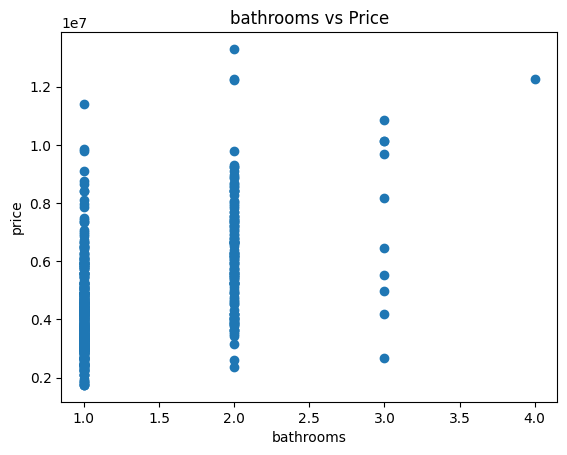

In [ ]:

features = ["area", "bedrooms", "bathrooms"]

for col in features:
    plt.figure()
    plt.scatter(df[col], df["price"])
    plt.xlabel(col)
    plt.ylabel("price")
    plt.title(f"{col} vs Price")
    plt.show()

In [8]:

# Pipeline
pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])


In [17]:

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [18]:

# Train
pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object'))])),
                ('model', LinearRegression())])

In [19]:

# Predict
y_pred = pipeline.predict(X_test)


In [20]:

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2:", r2)


MSE: 1754318687330.6682
R2: 0.6529242642153175


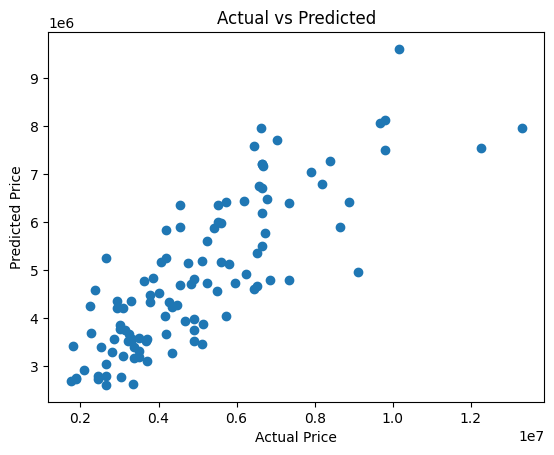

In [21]:

# Actual vs Predicted
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()


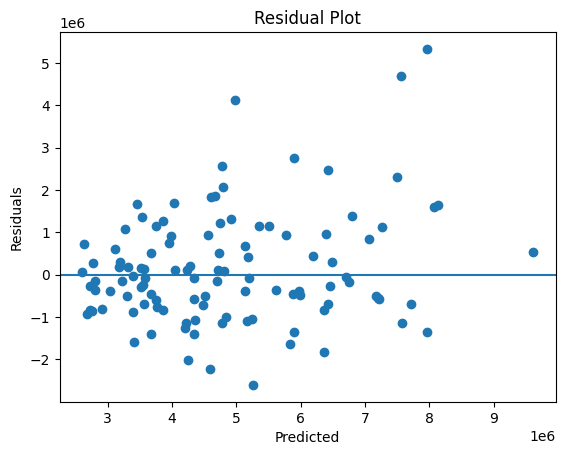

In [22]:

# Residual plot
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


In [23]:

# Feature Importance (Coefficients)
feature_names = pipeline.named_steps["preprocess"].get_feature_names_out()
coefficients = pipeline.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df["Abs"] = np.abs(coef_df["Coefficient"])
coef_df.sort_values(by="Abs", ascending=False).head(10)


,Feature,Coefficient,Abs
2,num__bathrooms,521879.027748,521879.027748
0,num__area,519552.416340,519552.416340
14,cat__airconditioning_yes,395713.367922,395713.367922
13,cat__airconditioning_no,-395713.367922,395713.367922
3,num__stories,349251.438906,349251.438906
11,cat__hotwaterheating_no,-342324.942669,342324.942669
12,cat__hotwaterheating_yes,342324.942669,342324.942669
16,cat__prefarea_yes,314945.282657,314945.282657
15,cat__prefarea_no,-314945.282657,314945.282657
19,cat__furnishingstatus_unfurnished,-233469.435624,233469.435624
